In [149]:
import pandas as pd
import numpy as np

### creating array and performing element wise operation on the array

In [150]:
test_array = np.exp(np.array([i for i in range(1,11)]).reshape(2,5))
test_array

array([[2.71828183e+00, 7.38905610e+00, 2.00855369e+01, 5.45981500e+01,
        1.48413159e+02],
       [4.03428793e+02, 1.09663316e+03, 2.98095799e+03, 8.10308393e+03,
        2.20264658e+04]])

### comparing the execution time for loop and vectorized operations


In [151]:
%%timeit

array = test_array.ravel()
for i in range(len(array)):
    array[i] = np.log(array[i])

<magic-timeit>:3: RuntimeWarning: divide by zero encountered in log
<magic-timeit>:3: RuntimeWarning: invalid value encountered in log


11.8 µs ± 51.6 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [152]:
%%timeit

array = test_array.ravel()

vec_array = np.log(array)

778 ns ± 13 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


#### As expected, the vectorized operations are much more faster than standard loop operations!

### Reading the data and getting the head, info, numerical summary, and group summary by category.

In [153]:
test_data = pd.read_csv('../data/starter_data.csv')

In [154]:
# first 5 entries of the data

test_data.head(5)

,category,value,date
0,A,10,2025-08-01
1,B,15,2025-08-02
2,A,12,2025-08-03
3,B,18,2025-08-04
4,C,25,2025-08-05


In [155]:
# getting concise summary of the data

test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  10 non-null     object
 1   value     10 non-null     int64 
 2   date      10 non-null     object
dtypes: int64(1), object(2)
memory usage: 368.0+ bytes


In [156]:
# filtering numeric column and describing it

numerical_summary = test_data['value'].describe()
print(numerical_summary)

count    10.000000
mean     17.600000
std       7.381659
min      10.000000
25%      12.250000
50%      14.500000
75%      23.250000
max      30.000000
Name: value, dtype: float64


In [157]:
# performing group by 'category' and aggregating

aggregated_summary = test_data.groupby('category').sum(numeric_only=True)
aggregated_summary

,value
category,
A,46
B,47
C,83


### saving the numerical and aggregate summary in json files in data/processed folder

In [158]:
import os

file_names = ['numerical_summary.json', 'aggregated_summary.json']

for file in file_names:
    os.makedirs(os.path.dirname(f'../data/processed/{file}'), exist_ok=True)

In [159]:
# saving the summary stats

with open('../data/processed/summary.json', 'w') as cont:
    cont.write(numerical_summary.to_json())

numerical_summary.to_json('../data/processed/numerical_summary.json')
aggregated_summary.to_json('../data/processed/aggregated_summary.json')

In [160]:
# creating plot for the data

test_data = test_data.set_index('date')

In [161]:
test_data

,category,value
date,,
2025-08-01,A,10
2025-08-02,B,15
2025-08-03,A,12
2025-08-04,B,18
2025-08-05,C,25
2025-08-06,C,30
2025-08-07,A,11
2025-08-08,B,14
2025-08-09,C,28


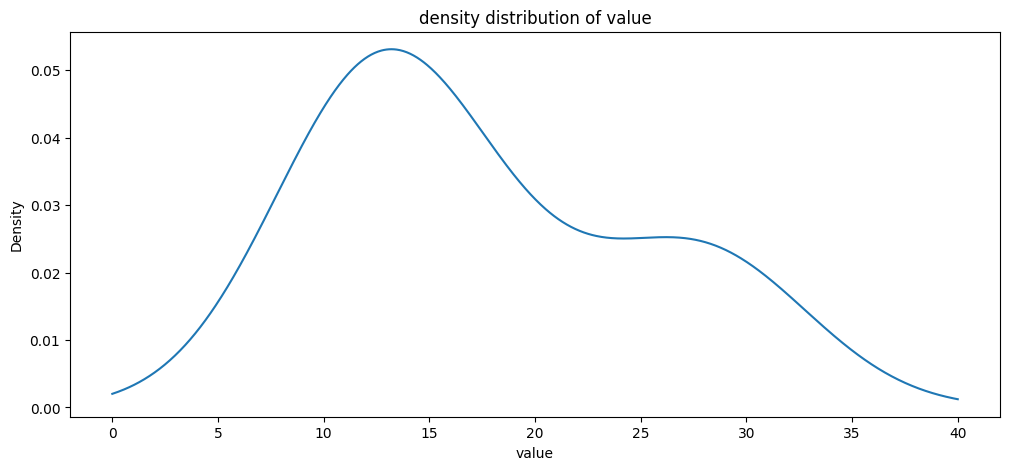

In [162]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12,5))
test_data['value'].plot(kind = 'kde', label = 'kde for values')
plt.xlabel('value')
plt.title('density distribution of value')
plt.savefig('../data/kde.jpg')

### defining function for summary stats

In [163]:
def summary_stats(dataframe, groupby_column = None):
    
    results = {}
    
    results['full_data'] = dataframe.describe().to_dict()
    
    groupby_results = dataframe.groupby(groupby_column).agg(['std','mean','median'])
    results['grouped_data'] = groupby_results.to_dict()
    
    return results

In [164]:
summary_stats(dataframe=test_data, groupby_column='category')

{'full_data': {'value': {'count': 10.0,
   'mean': 17.6,
   'std': 7.381658952355418,
   'min': 10.0,
   '25%': 12.25,
   '50%': 14.5,
   '75%': 23.25,
   'max': 30.0}},
 'grouped_data': {('value', 'std'): {'A': 1.2909944487358056,
   'B': 2.0816659994661326,
   'C': 2.516611478423583},
  ('value', 'mean'): {'A': 11.5,
   'B': 15.666666666666666,
   'C': 27.666666666666668},
  ('value', 'median'): {'A': 11.5, 'B': 15.0, 'C': 28.0}}}